Encoding in python

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import OneHotEncoder

In [2]:
iris = load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [13]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
print(df.iloc[[25, 75, 125]].T)

                   25   75   125
sepal length (cm)  5.0  6.6  7.2
sepal width (cm)   3.0  3.0  3.2
petal length (cm)  1.6  4.4  6.0
petal width (cm)   0.2  1.4  1.8
target             0.0  1.0  2.0


1. One-Hot Encoding

In [14]:
# conversione dei valori numerici in stringhe target
df["target"] = df["target"].map({ 0: "setosa", 1: "versicolor", 2: "virginica"})
print(df.iloc[[25, 75, 125]].T)


                      25          75         125
sepal length (cm)     5.0         6.6        7.2
sepal width (cm)      3.0         3.0        3.2
petal length (cm)     1.6         4.4        6.0
petal width (cm)      0.2         1.4        1.8
target             setosa  versicolor  virginica


1. One Hot Encoding

In [15]:
# creazione dell'encoder
encoder = OneHotEncoder(sparse_output=False)
encoder_ohe = encoder.fit_transform(df[["target"]])
ohe_cols = encoder.get_feature_names_out(["target"])

# creazione del df con le nuove colonne del ohe
df_ohe = pd.concat([df, pd.DataFrame(encoder_ohe, columns=ohe_cols)], axis=1)
print(df_ohe.iloc[[25, 75, 125]].T)


                      25          75         125
sepal length (cm)     5.0         6.6        7.2
sepal width (cm)      3.0         3.0        3.2
petal length (cm)     1.6         4.4        6.0
petal width (cm)      0.2         1.4        1.8
target             setosa  versicolor  virginica
target_setosa         1.0         0.0        0.0
target_versicolor     0.0         1.0        0.0
target_virginica      0.0         0.0        1.0


2. Dummy Coding

In [16]:
encoded_dummy = pd.get_dummies(df["target"], drop_first=True, dtype=int)
# questo metodo prende il primo valore e lo prende come riferimento, prendendo come k-1 colonne
df_dummy = pd.concat([df, encoded_dummy], axis=1)
print(df_dummy.iloc[[25, 75, 125]].T)

                      25          75         125
sepal length (cm)     5.0         6.6        7.2
sepal width (cm)      3.0         3.0        3.2
petal length (cm)     1.6         4.4        6.0
petal width (cm)      0.2         1.4        1.8
target             setosa  versicolor  virginica
versicolor              0           1          0
virginica               0           0          1


3. Effect Coding

In [17]:
effect = pd.get_dummies(df["target"], dtype=int)

reference_col = "setosa"
effect[reference_col] = effect[reference_col].replace(1, -1)

df_effect = pd.concat([df, effect], axis=1)

print(df_effect.iloc[[25, 75, 125]].T)

                      25          75         125
sepal length (cm)     5.0         6.6        7.2
sepal width (cm)      3.0         3.0        3.2
petal length (cm)     1.6         4.4        6.0
petal width (cm)      0.2         1.4        1.8
target             setosa  versicolor  virginica
setosa                 -1           0          0
versicolor              0           1          0
virginica               0           0          1


4. Visualizzazione encodind

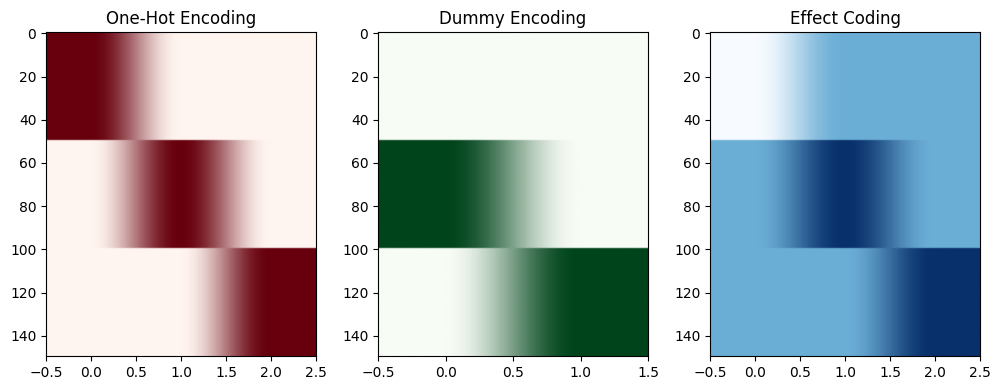

In [18]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(df_ohe[ohe_cols].values, cmap="Reds", aspect="auto")
plt.title("One-Hot Encoding")

plt.subplot(1, 3, 2)
plt.imshow(df_dummy[encoded_dummy.columns].values, cmap="Greens", aspect="auto")
plt.title("Dummy Encoding")

plt.subplot(1, 3, 3)
plt.imshow(df_effect[["setosa", "versicolor", "virginica"]], cmap="Blues", aspect="auto")
plt.title("Effect Coding") 

plt.tight_layout()
plt.show()
